In [1]:
import platform
platform.platform()

'macOS-26.2-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt

In [6]:
import pandas as pd
pd.__version__

'2.3.3'

In [7]:
from rdkit import rdBase
rdBase.rdkitVersion

'2023.09.1'

In [8]:
from SSMetrics import ecfp_metrics

In [9]:
df1 = pd.read_csv("../../../1_dataset/1_28descriptors/1_dataset/1_original/dataset.csv",
                  usecols=["InChI",
                          "K3FeCN6", "MesAcr+BF4-", "CuCl",
                          "Diacetyl", "T(p-OMe)PPCo", "Electrode"])
df1.shape

(4665, 7)

In [10]:
df1.columns

Index(['InChI', 'K3FeCN6', 'MesAcr+BF4-', 'CuCl', 'Diacetyl', 'T(p-OMe)PPCo',
       'Electrode'],
      dtype='object')

In [11]:
conditions = [["K3FeCN6",(255/255, 75/255, 0/255), "K$_3$[Fe(CN)$_6$]"],
              ["MesAcr+BF4-", (153/255, 0/255, 153/255), "MesAcr$^+$BF$_4^-$"],
              ["CuCl", (3/255, 175/255, 122/255), "CuCl"],
              ["Diacetyl", (246/255, 170/255, 0/255), "Diacetyl"],
              ["T(p-OMe)PPCo", (77/255, 196/255, 255/255), "T($p$-OMe)PPCo"],
              ["Electrode", (255/255, 128/255, 130/255), "Electrode"]]

In [12]:
li_numbers = []
li_2_2048 = []
li_2_4096 = []
li_3_2048 = []
li_3_4096 = []
li_4_2048 = []
li_4_4096 = []

In [13]:
def calc(li, radius, nBits, number):
    for i in range(6):
        condition = conditions[i][0]
        
        print(f"\n{condition}, {radius}, {nBits}")
        df2 = df1[df1[condition] == 1]

        if number:
            li_numbers.append(len(df2))

        inchi_list = df2["InChI"].to_list()
        ss = ecfp_metrics.on_bits(inchi_list, radius, nBits)
        li.append(ss[0])

In [14]:
calc(li_2_2048, 2, 2048, True)
calc(li_2_4096, 2, 4096, False)
calc(li_3_2048, 3, 2048, False)
calc(li_3_4096, 3, 4096, False)
calc(li_4_2048, 4, 2048, False)
calc(li_4_4096, 4, 4096, False)


K3FeCN6, 2, 2048
117

MesAcr+BF4-, 2, 2048
124

CuCl, 2, 2048
102

Diacetyl, 2, 2048
77

T(p-OMe)PPCo, 2, 2048
77

Electrode, 2, 2048
87

K3FeCN6, 2, 4096
119

MesAcr+BF4-, 2, 4096
129

CuCl, 2, 4096
105

Diacetyl, 2, 4096
77

T(p-OMe)PPCo, 2, 4096
80

Electrode, 2, 4096
89

K3FeCN6, 3, 2048
200

MesAcr+BF4-, 3, 2048
208

CuCl, 3, 2048
197

Diacetyl, 3, 2048
135

T(p-OMe)PPCo, 3, 2048
120

Electrode, 3, 2048
127

K3FeCN6, 3, 4096
204

MesAcr+BF4-, 3, 4096
214

CuCl, 3, 4096
204

Diacetyl, 3, 4096
136

T(p-OMe)PPCo, 3, 4096
123

Electrode, 3, 4096
131

K3FeCN6, 4, 2048
231

MesAcr+BF4-, 4, 2048
241

CuCl, 4, 2048
248

Diacetyl, 4, 2048
151

T(p-OMe)PPCo, 4, 2048
128

Electrode, 4, 2048
130

K3FeCN6, 4, 4096
240

MesAcr+BF4-, 4, 4096
248

CuCl, 4, 4096
259

Diacetyl, 4, 4096
152

T(p-OMe)PPCo, 4, 4096
131

Electrode, 4, 4096
135


In [15]:
labels = []

for i in range(6):
    labels.append(f"{conditions[i][2]} ({li_numbers[i]})")
    
labels

['K$_3$[Fe(CN)$_6$] (23)',
 'MesAcr$^+$BF$_4^-$ (20)',
 'CuCl (19)',
 'Diacetyl (12)',
 'T($p$-OMe)PPCo (9)',
 'Electrode (9)']

In [16]:
df_result = pd.DataFrame({"Condition": [e[0] for e in conditions],
                          "Number":li_numbers})

df_result["radius=2,\nnBits=2048"] = li_2_2048
df_result["radius=2,\nnBits=4096"] = li_2_4096
df_result["radius=3,\nnBits=2048"] = li_3_2048
df_result["radius=3,\nnBits=4096"] = li_3_4096
df_result["radius=4,\nnBits=2048"] = li_4_2048
df_result["radius=4,\nnBits=4096"] = li_4_4096

df_result

,Condition,Number,"radius=2,\nnBits=2048","radius=2,\nnBits=4096","radius=3,\nnBits=2048","radius=3,\nnBits=4096","radius=4,\nnBits=2048","radius=4,\nnBits=4096"
0,K3FeCN6,23,117,119,200,204,231,240
1,MesAcr+BF4-,20,124,129,208,214,241,248
2,CuCl,19,102,105,197,204,248,259
3,Diacetyl,12,77,77,135,136,151,152
4,T(p-OMe)PPCo,9,77,80,120,123,128,131
5,Electrode,9,87,89,127,131,130,135


In [17]:
df_result.to_csv("si_ecfp_OnBits.csv", index=False)

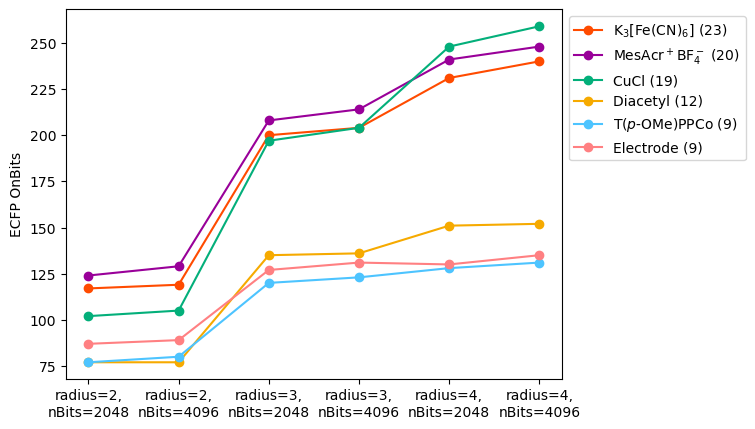

In [18]:
fig = plt.figure()
ax = fig.add_subplot()

for i in range(6):
    ax.plot(
        df_result.iloc[i, 2:],
        marker="o",
        color=conditions[i][1],
        label=labels[i]
        )

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel("ECFP OnBits")

plt.savefig("si_ecfp_OnBits.png", dpi=300, bbox_inches="tight")
plt.show()